In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sleap
import numpy as np

from matplotlib.patches import ConnectionPatch
from pathlib import Path

import sleap_roots_training

from sleap_roots_training.evaluate import main

In [2]:
# import wandb
# run = wandb.init()
# artifact = run.use_artifact('eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/rice-primary-2025-01-19_v002:v0', type='model')
# artifact_dir = artifact.download()

In [3]:
# Constants for W&B initialization config
ENTITY_NAME = "eberrigan-salk-institute-for-biological-studies"
PROJECT_NAME = "sleap-roots"
REGISTRY = "sleap-roots-models"
EXPERIMENT_NAME = "primary-root-model-comparison-2025-02-20"

# Constants for artifacts
TAGS = ["rice3-5DAG", "soybean6-8DAG", "sorghum5-12DAG", "soybean", "sorghum", "canola2-13DAG", "canola", "pennycress", "arabidopsis", "pennycress14DAG", "arabidopsis7-11DAG", "primary", "2025-02-20", "rice"]
GROUPS = ["sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20", "canola-pennycress-arabidopsis-primary-2025-01-20", "canola-primary-2025-01-19", "pennycress-primary-2025-01-19", "arabidopsis-primary-2025-01-19", "rice-primary-2025-01-19", "sorghum-soybean-primary-2025-01-07", "sorghum-primary-2025-01-06", "soybean-primary-2025-01-05"]
VERSIONS = ["000", "001", "002"]
ARTIFACT_NAME = "primary-root-model-metrics"
CSV_PATH = "metrics.csv"
H5S_PATH = "poster_results"

In [4]:
GROUPS_VIZ = ["sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20", 
              "canola-pennycress-arabidopsis-primary-2025-01-20", 
              "canola-primary-2025-01-19", 
              "rice-primary-2025-01-19", 
              "sorghum-soybean-primary-2025-01-07", 
              "soybean-primary-2025-01-05"]

In [5]:
poster_font_settings = {
    "font.size": 50,
    "axes.labelsize": 28,
    "axes.titlesize": 30,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 22,
    "font.family": "sans-serif",
    "font.weight": "bold",
}

In [6]:
sleap_roots_training.reset_config()

Configuration updated successfully at e:\repositories\sleap-roots-training\sleap_roots_training\config.yaml.
Configuration has been reset to default values.


In [7]:
sleap_roots_training.update_config(entity_name=ENTITY_NAME, project_name=PROJECT_NAME, registry=REGISTRY, experiment_name=EXPERIMENT_NAME)

Configuration updated successfully at e:\repositories\sleap-roots-training\sleap_roots_training\config.yaml.
CONFIG updated to {'project_name': 'sleap-roots', 'entity_name': 'eberrigan-salk-institute-for-biological-studies', 'experiment_name': 'primary-root-model-comparison-2025-02-20', 'registry': 'sleap-roots-models', 'collection_name': None, 'job_type': None}.


In [8]:
list_of_files = Path(H5S_PATH).glob("*.h5")
list_of_files = [file.as_posix() for file in list_of_files]
list_of_files

['poster_results/arabidopsis_20DAG.h5',
 'poster_results/canola_7DAG.h5',
 'poster_results/rice_3DAG.h5',
 'poster_results/soybean_6DAG.h5']

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: eberrigan (eberrigan-salk-institute-for-biological-studies). Use `wandb login --relogin` to force relogin


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20_v002:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.
wandb: Downloading large artifact sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20_v002:latest, 331.10MB. 260 files... 
wandb:   260 of 260 files downloaded.  
Done. 0:0:1.0


Downloaded artifact: sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20_v002 to e:\repositories\sleap-roots-training\artifacts\sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20_v002-v0
Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/canola-pennycress-arabidopsis-primary-2025-01-20_v002:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.
wandb: Downloading large artifact canola-pennycress-arabidopsis-primary-2025-01-20_v002:latest, 220.13MB. 172 files... 
wandb:   172 of 172 files downloaded.  
Done. 0:0:0.7


...

Downloaded artifact: sorghum-soybean-primary-2025-01-07_v002 to e:\repositories\sleap-roots-training\artifacts\sorghum-soybean-primary-2025-01-07_v002-v0


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/soybean-primary-2025-01-05_v002:latest


wandb: Downloading large artifact soybean-primary-2025-01-05_v002:latest, 63.41MB. 16 files... 
wandb:   16 of 16 files downloaded.  
Done. 0:0:0.3


Downloaded artifact: soybean-primary-2025-01-05_v002 to e:\repositories\sleap-roots-training\artifacts\soybean-primary-2025-01-05_v002-v0
Saved grid visualization to poster_results/grid_predictions_frame_1.png


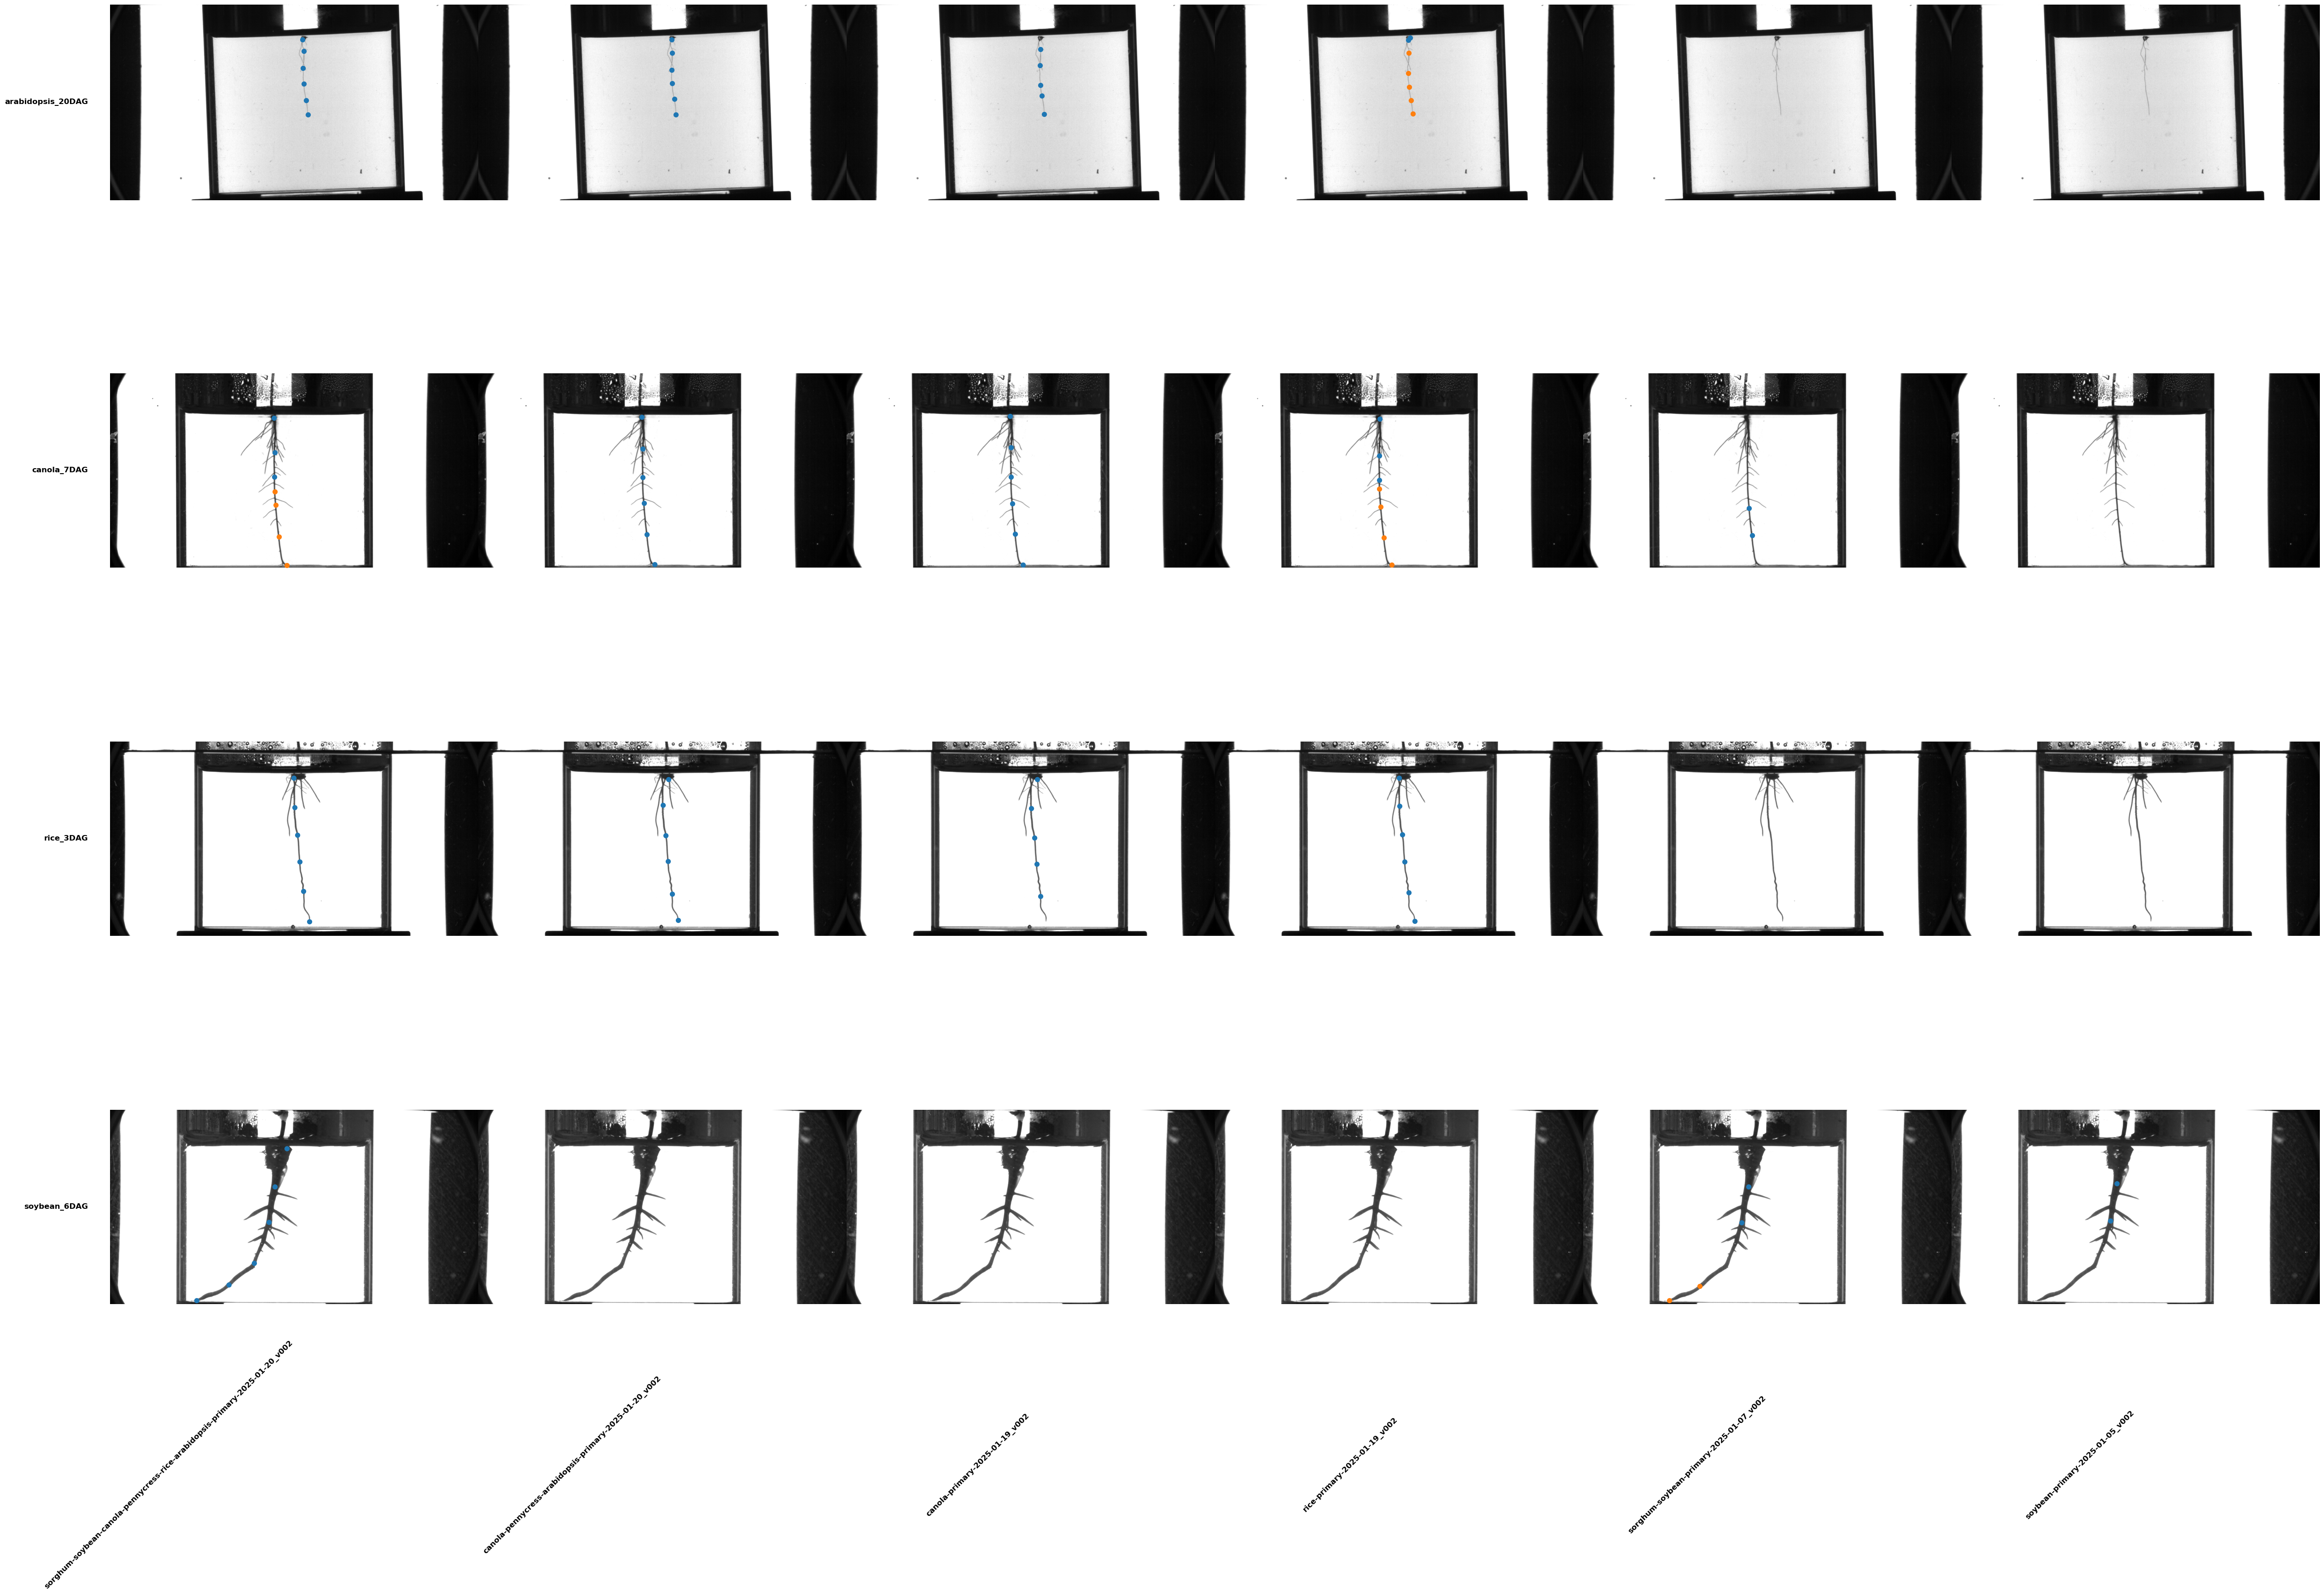

In [9]:
sleap_roots_training.predictions_viz_multiple_files(
    output_dir="poster_results",
    filenames=list_of_files,
    groups=GROUPS_VIZ,
    tags=TAGS,
    frame_idx=1,
    model_version="002",
    overwrite=False,
    figsize_scale=8,  # Larger figure for better visibility
    dpi=600,  # High-resolution print quality
    transparent=True,  # Transparent background for poster overlay
    font_settings=poster_font_settings,  # Apply poster fonts
    colormap="viridis",  # High-contrast colormap
    spacing={
        "left": 0.00,
        "right": 1.00,
        "top": 1.00,
        "bottom": 0.00,
        "wspace": 0.0,
        "hspace": 0.0,
    }
)


In [10]:
metrics = main(groups=GROUPS, versions=VERSIONS, tags=TAGS, csv_path=CSV_PATH)

Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20_v000:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20_v001:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/sorghum-soybean-canola-pennycress-rice-arabidopsis-primary-2025-01-20_v002:latest


...

Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/soybean-primary-2025-01-05_v000:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/soybean-primary-2025-01-05_v001:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/soybean-primary-2025-01-05_v002:latest
Metrics saved to metrics.csv


In [11]:
# metric = "dist_avg"

# # Load metrics file
# file_path = CSV_PATH
# df = pd.read_csv(file_path)

# # Abbreviate group names to only the part before "-primary"
# df["group_name"] = df["group"].str.split("-primary").str[0]

# # Define the custom order for group names
# custom_order = ["rice", "sorghum", "soybean", "sorghum-soybean", "canola", "pennycress", "arabidopsis", "canola-pennycress-arabidopsis", "sorghum-soybean-canola-pennycress-rice-arabidopsis"]

# # Set the custom order in the DataFrame
# df["group_name"] = pd.Categorical(df["group_name"], categories=custom_order, ordered=True)

# # Create the bar plot for dist_avg
# plt.figure(figsize=(10, 8))
# sns.barplot(data=df, x="group_name", y=metric)

# plt.title("Comparison of Average Error Across Groups")
# plt.xlabel("Group")
# plt.ylabel("Average Error (mm)")
# plt.grid(axis="y")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()

# # Save the plot to a file
# plt.savefig("primary_root_average_error_comparison.png")

# # Display the plot
# plt.show()

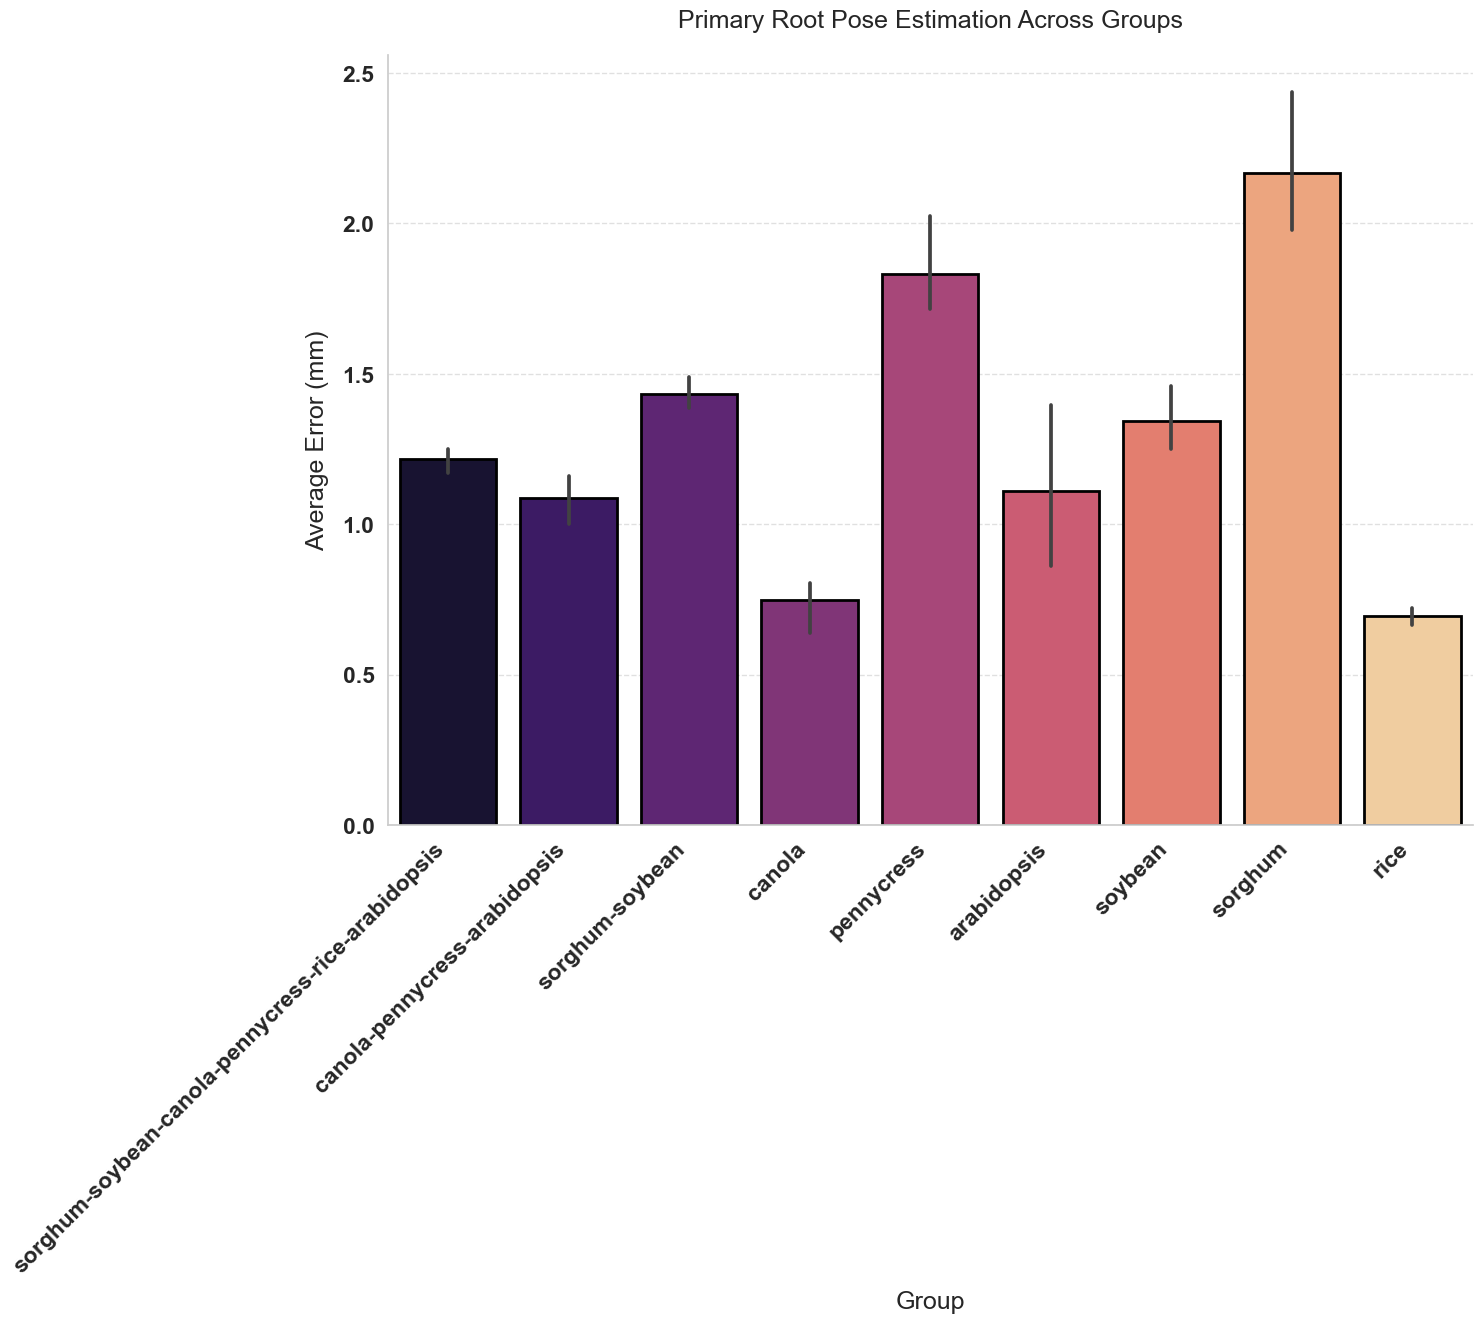

In [14]:
# Apply global font settings
plt.rcParams.update(poster_font_settings)

# Load data
file_path = CSV_PATH
df = pd.read_csv(file_path)

# Abbreviate group names to only the part before "-primary"
df["group_name"] = df["group"].str.split("-primary").str[0]

# Custom order for better comparison
custom_order = [
    "sorghum-soybean-canola-pennycress-rice-arabidopsis",
    "canola-pennycress-arabidopsis",
    "sorghum-soybean",
    "canola",
    "pennycress",
    "arabidopsis",
    "soybean",
    "sorghum",
    "rice",
]

df["group_name"] = pd.Categorical(df["group_name"], categories=custom_order, ordered=True)

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.5)

# Create bar plot
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=df, x="group_name", y="dist_avg", 
    palette="magma", edgecolor="black", linewidth=2
)

# Customize labels and title
plt.title("Primary Root Pose Estimation Across Groups", pad=20)
plt.xlabel("Group", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

# Adjust x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Remove unnecessary spines and add subtle grid
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Save high-resolution plot
plt.savefig(Path("poster_results") / "primary_root_average_error_comparison.png", dpi=600, bbox_inches="tight", transparent=True)

# Show plot
plt.show()



In [ ]:
# Add the plot to the W&B metrics artifact

# Initialize the W&B run
add_files_run = wandb.init(project=PROJECT_NAME, entity=ENTITY_NAME, job_type="add_files_to_artifact")

# Use the existing artifact and download its contents
metrics_artifact = add_files_run.use_artifact(f"{ARTIFACT_NAME}:latest", type="metrics")
artifact_dir = Path(metrics_artifact.download())
print(f"Artifact downloaded to {artifact_dir}")

# Create a new artifact
new_metrics_artifact = wandb.Artifact(name=ARTIFACT_NAME, type="metrics")

# Add the bar plot to the new artifact
new_metrics_artifact.add_file("primary_root_average_error_comparison.png")

# Add the grid visualization to the new artifact
new_metrics_artifact.add_file("output/grid_predictions_frame_1.png")

# Add the predictions images to the new artifact
new_metrics_artifact.add_dir("prediction_viz")

# Add the files from the existing artifact
for file_path in artifact_dir.iterdir():
    new_metrics_artifact.add_file(file_path)

# Log the new artifact
add_files_run.log_artifact(new_metrics_artifact)

# Finish the run
add_files_run.finish()